In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# for boosting use:
from sklearn.ensemble import GradientBoostingClassifier  # built-in
# or for better performance:
import xgboost as xgb

In [2]:
# Relative path from notebooks/data_load.ipynb to data/processed/FW_Veg_Rem_Combined.csv
df = pd.read_csv('../data/processed/FW_Veg_Rem_Combined_cleaned.csv')
df.head()

,fire_size,fire_size_class,latitude,longitude,discovery_month,disc_pre_year,Vegetation,Temp_pre_30,Temp_pre_15,Temp_pre_7,...,Wind_pre_15,Wind_pre_7,Hum_pre_30,Hum_pre_15,Hum_pre_7,Prec_pre_30,Prec_pre_15,Prec_pre_7,remoteness,fire_size_class_B
0,10.0,C,18.105072,-66.753044,Feb,2007,12,24.480974,24.716923,24.902597,...,3.492857,3.262092,78.216590,76.793750,76.381579,0.0,0.0,0.0,0.017923,0
1,3.0,B,35.038330,-87.610000,Dec,2006,15,7.553433,7.010000,0.343529,...,2.881707,1.976471,70.840000,65.858911,55.505882,59.8,8.4,0.0,0.184355,1
2,60.0,C,34.947800,-88.722500,Feb,2004,16,4.971930,5.782766,5.558750,...,2.923830,2.695833,75.531629,75.868613,76.812834,168.8,42.2,18.1,0.194544,0
3,1.0,B,39.641400,-119.308300,Jun,2005,0,16.275967,18.996181,18.142564,...,3.398329,3.671282,44.778429,37.140811,35.353846,10.4,7.2,0.0,0.487447,1
4,5.2,B,31.316978,-83.393649,Jan,2008,12,14.877341,16.409326,17.941312,...,1.727202,1.454190,79.896679,73.431818,66.966957,26.0,0.0,0.0,0.148904,1


In [ ]:
X = df.drop(['fire_size_class', 'fire_size_class_B','fire_size'], axis=1)
y = df['fire_size_class']

Encode 'discovery_month' (cyclical encoding) - Convert month strings to numbers (if needed)


In [4]:
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
if X["discovery_month"].dtype == "object":
    X["discovery_month"] = X["discovery_month"].map(month_map)

# Create sine/cosine features
X["month_sin"] = np.sin(2 * np.pi * X["discovery_month"] / 12)
X["month_cos"] = np.cos(2 * np.pi * X["discovery_month"] / 12)

# Drop original month column
X.drop("discovery_month", axis=1, inplace=True)

Splits your dataset into training and testing sets: random_state=42 ensures the split is reproducible


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scikit learning gradent boosting model

In [15]:
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)
## no grid search applied, so this is a model with default hyperparameters and therefore still long way to go
## outstanding are valuation metrics (confusion matrix and classification report)

GradientBoostingClassifier(random_state=42)

In [7]:
param_grid_first = {
    'n_estimators': [100],
    'max_depth': [None, 10],
    'max_features': ['sqrt'],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

In [30]:
# Evaluating first model with accuracy, confusion matrix and classification report
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
confusion_matrix = confusion_matrix(y_test, y_pred)
classification_report = classification_report(y_test, y_pred)
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion_matrix)
print("Classification Report:", classification_report)

NameError: name 'model' is not defined

XGBOOST GRADENT BOOSTING MODEL


In [6]:
# Transforming dependent variable to numerical values
# Create a LabelEncoder object
le = LabelEncoder()

# Fit it on the y_train and transform
y_train_encoded = le.fit_transform(y_train)

# Also encode y_test with the same encoder
y_test_encoded = le.transform(y_test)

In [8]:
xgb_model = xgb.XGBClassifier(n_estimators=75, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=75,
              n_jobs=None, num_parallel_tree=None, ...)

evaluating the model

In [9]:
y_pred_encoded = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
conf_matrix = confusion_matrix(y_test_encoded, y_pred_encoded)  # Renamed variable
class_report = classification_report(y_test_encoded, y_pred_encoded)  # Renamed variable
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:", class_report)

Accuracy: 0.7194302606826122
Confusion Matrix:
 [[4834   17    0    0    1    3]
 [1445    9    0    0    1    2]
 [ 201    5    0    0    0    1]
 [  91    3    0    0    0    0]
 [  58    5    0    0   23  191]
 [  36    0    0    0   28  488]]
Classification Report:               precision    recall  f1-score   support

           0       0.73      1.00      0.84      4855
           1       0.23      0.01      0.01      1457
           2       0.00      0.00      0.00       207
           3       0.00      0.00      0.00        94
           4       0.43      0.08      0.14       277
           5       0.71      0.88      0.79       552

    accuracy                           0.72      7442
   macro avg       0.35      0.33      0.30      7442
weighted avg       0.59      0.72      0.61      7442



/Users/williamfreiherrtuchervonsimmelsdorf/BigDataProject/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/williamfreiherrtuchervonsimmelsdorf/BigDataProject/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/williamfreiherrtuchervonsimmelsdorf/BigDataProject/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division`

In [20]:
param_grid_first = {
    'n_estimators': [100],
    'max_depth': [None, 7],
    'max_features': ['sqrt'],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

grid_search_first = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_first,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)
grid_search_first.fit(X_train, y_train)

print(grid_search_first.best_params_)
print(grid_search_first.best_score_)


Fitting 3 folds for each of 2 candidates, totalling 6 fits


/Users/williamfreiherrtuchervonsimmelsdorf/BigDataProject/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [09:59:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "max_features", "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/williamfreiherrtuchervonsimmelsdorf/BigDataProject/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [09:59:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "max_features", "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/williamfreiherrtuchervonsimmelsdorf/BigDataProject/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [09:59:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "max_features", "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration

[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=7, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=7, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=7, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
0.7448767049653968


/Users/williamfreiherrtuchervonsimmelsdorf/BigDataProject/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [09:59:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "max_features", "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [21]:
# Hyperparameter tuning using GridSearchCV
param_grid = {
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [4, 5, 6],
    'n_estimators': [50, 75, 100]
}

xgb_model = xgb.XGBClassifier()

grid_search = GridSearchCV(estimator=xgb_model,
                           param_grid=param_grid,
                           scoring='accuracy',  # or 'f1_weighted' if multiclass
                           cv=3,  # 3-fold cross-validation
                           verbose=1,  # shows progress
                           n_jobs=-1)  # use all CPU cores

grid_search.fit(X_train, y_train_encoded)


Fitting 3 folds for each of 27 candidates, totalling 81 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1, 0.15],
                         'max_depth': [4, 5, 6],
                         'n_estimators': [50, 75, 100]},
             scoring='accuracy', verbose=1)

In [22]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 75}
0.7230733051132163


In [ ]:
# Reversing the numerical values to oriiginal labels
y_pred_labels = le.inverse_transform(y_pred)


See which variables are most important!

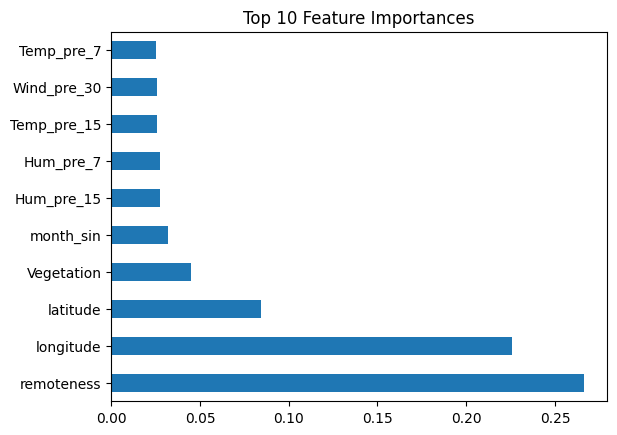

In [53]:

# 🔍 Feature Importance
feature_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()

NEW MODEL WITH DEPENDENT DUMMY VARIABLE
We use fire_size_class_B as our dependent variable now. 

In [12]:
df = pd.read_csv('../data/processed/FW_Veg_Rem_Combined_cleaned.csv')
X = df.drop(['fire_size_class', 'fire_size_class_B','fire_size'], axis=1)
y = df['fire_size_class_B']

month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
if X["discovery_month"].dtype == "object":
    X["discovery_month"] = X["discovery_month"].map(month_map)

# Create sine/cosine features
X["month_sin"] = np.sin(2 * np.pi * X["discovery_month"] / 12)
X["month_cos"] = np.cos(2 * np.pi * X["discovery_month"] / 12)

# Drop original month column
X.drop("discovery_month", axis=1, inplace=True)



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


xgb_model_dummy = xgb.XGBClassifier(n_estimators=75, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model_dummy.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=75,
              n_jobs=None, num_parallel_tree=None, ...)

In [15]:
y_pred_dummy = xgb_model_dummy.predict(X_test)
accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
conf_matrix_dummy = confusion_matrix(y_test, y_pred_dummy)  # Renamed variable
class_report_dummy = classification_report(y_test, y_pred_dummy)  # Renamed variable
print("Accuracy:", accuracy_dummy)
print("Confusion Matrix:\n", conf_matrix_dummy)
print("Classification Report:", class_report_dummy)

Accuracy: 0.750470303681806
Confusion Matrix:
 [[ 870 1717]
 [ 140 4715]]
Classification Report:               precision    recall  f1-score   support

           0       0.86      0.34      0.48      2587
           1       0.73      0.97      0.84      4855

    accuracy                           0.75      7442
   macro avg       0.80      0.65      0.66      7442
weighted avg       0.78      0.75      0.71      7442



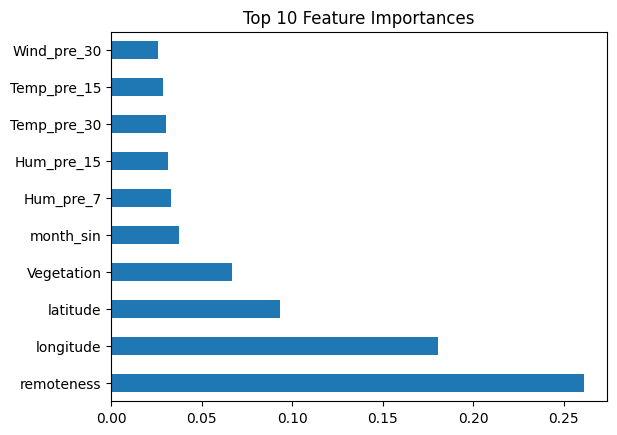

In [16]:
# 🔍 Feature Importance
feature_importances = pd.Series(xgb_model_dummy.feature_importances_, index=X_train.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()